In [ ]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

spark = SparkSession.builder \
    .appName("HotelBooking_SQL_Chan") \
    .master("local[*]") \
    .config('spark.hadoop.fs.defaultFS', 'hdfs://localhost:9000') \
    .getOrCreate()

df = spark.read.csv(
    "hdfs://localhost:9000/data/hotel_bookingss_preprocessed.csv",
    header=True, inferSchema=True
)
df.createOrReplaceTempView("hotel_bookings")
print(f"✓ Dataset: {df.count():,} bản ghi  |  {len(df.columns)} cột")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/14 07:33:53 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/06/14 07:33:53 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/14 07:33:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable



[Stage 0:>                                                          (0 + 1) / 1]



✓ Dataset: 118,321 bản ghi  |  35 cột


In [3]:
# ── Cấu hình style biểu đồ dùng chung ──────────────────────────────────────
COLORS = {
    "city"   : "#2563EB",
    "resort" : "#F59E0B",
    "green"  : "#10B981",
    "red"    : "#EF4444",
    "purple" : "#8B5CF6",
    "navy"   : "#1E3A5F",
    "gray"   : "#9CA3AF",
    "palette": ["#2563EB","#F59E0B","#10B981","#EF4444","#8B5CF6","#06B6D4","#EC4899","#84CC16"],
}

plt.rcParams.update({
    "figure.dpi"        : 120,
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
    "axes.titlepad"     : 12,
})
print("✓ Style sẵn sàng")

✓ Style sẵn sàng


Query 2: Tỷ lệ hủy đặt phòng theo loại khách sạn và xếp hạng từng năm

In [ ]:
df_q2 = spark.sql("""
WITH hotel_cancel AS (
    SELECT
        arrival_date_year,
        hotel,
        ROUND(AVG(is_canceled) * 100, 2) AS cancel_rate
    FROM hotel_bookings
    GROUP BY arrival_date_year, hotel
)
SELECT *,
       DENSE_RANK() OVER (
           PARTITION BY arrival_date_year
           ORDER BY cancel_rate DESC
       ) AS rank
FROM hotel_cancel
ORDER BY arrival_date_year, rank
""")
df_q2.show()

+-----------------+------------+-----------+----+
|arrival_date_year|       hotel|cancel_rate|rank|
+-----------------+------------+-----------+----+
|             2015|  City Hotel|      44.12|   1|
|             2015|Resort Hotel|      25.88|   2|
|             2016|  City Hotel|      40.63|   1|
|             2016|Resort Hotel|      26.82|   2|
|             2017|  City Hotel|      42.61|   1|
|             2017|Resort Hotel|      30.91|   2|
+-----------------+------------+-----------+----+



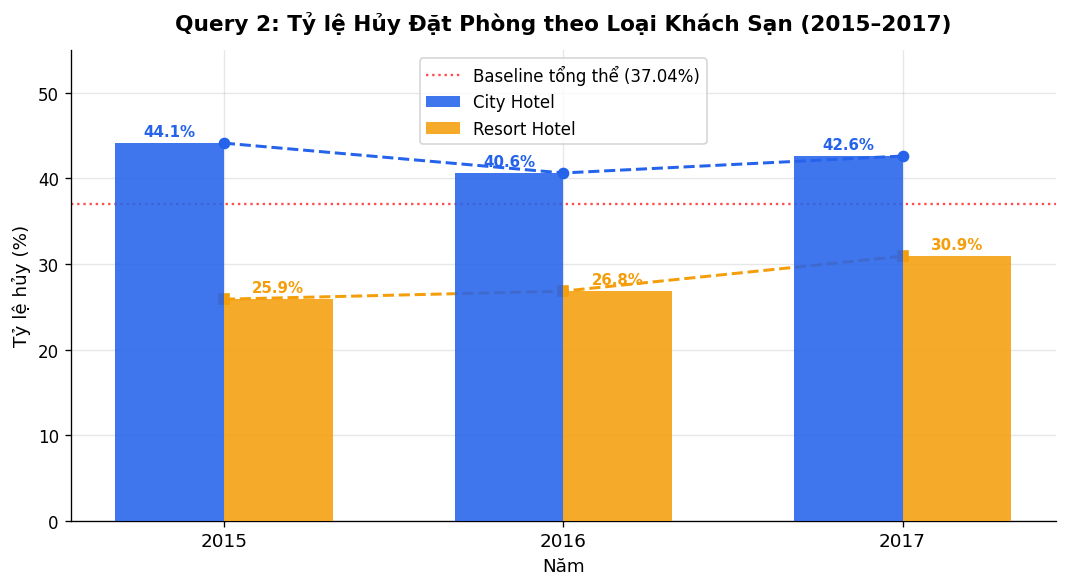

In [5]:
# ── Query 2: Biểu đồ ────────────────────────────────────────────────────────
data = df_q2.toPandas()

years    = sorted(data["arrival_date_year"].unique())
city_r   = data[data["hotel"]=="City Hotel"].set_index("arrival_date_year")["cancel_rate"]
resort_r = data[data["hotel"]=="Resort Hotel"].set_index("arrival_date_year")["cancel_rate"]

x = np.arange(len(years))
w = 0.32

fig, ax = plt.subplots(figsize=(9, 5))

# ── Grouped bar ──────────────────────────────────────────────────────────────
b1 = ax.bar(x - w/2, [city_r[y]   for y in years], w,
            label="City Hotel",   color=COLORS["city"],   alpha=0.88, zorder=3)
b2 = ax.bar(x + w/2, [resort_r[y] for y in years], w,
            label="Resort Hotel", color=COLORS["resort"], alpha=0.88, zorder=3)

# ── Đường xu hướng ──────────────────────────────────────────────────────────
ax.plot(x, [city_r[y]   for y in years], "o--", color=COLORS["city"],   lw=1.8, ms=6)
ax.plot(x, [resort_r[y] for y in years], "s--", color=COLORS["resort"], lw=1.8, ms=6)

# ── Nhãn giá trị ─────────────────────────────────────────────────────────────
for b in b1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=COLORS["city"])
for b in b2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            f"{b.get_height():.1f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=COLORS["resort"])

# ── Baseline tổng thể ────────────────────────────────────────────────────────
ax.axhline(37.04, color="red", ls=":", lw=1.4, alpha=0.7,
           label="Baseline tổng thể (37.04%)")

ax.set_xticks(x)
ax.set_xticklabels(years, fontsize=11)
ax.set_xlabel("Năm")
ax.set_ylabel("Tỷ lệ hủy (%)")
ax.set_ylim(0, 55)
ax.set_title("Query 2: Tỷ lệ Hủy Đặt Phòng theo Loại Khách Sạn (2015–2017)",
             fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

QUERY 4: Doanh thu phong thực tế và tiềm năng theo tháng

In [ ]:
df_q4 = spark.sql("""
WITH monthly_revenue AS (
    SELECT
        arrival_date_year,
        DATE_FORMAT(TO_DATE(arrival_date_month, 'MMMM'), 'MM') AS month_num,
        arrival_date_month AS month_name,
                  
        ROUND(SUM(adr * (stays_in_week_nights + stays_in_weekend_nights)), 2) AS revenue_potential,

        ROUND(SUM(
            CASE WHEN is_canceled = 0
                 THEN adr * (stays_in_week_nights + stays_in_weekend_nights)
                 ELSE 0 END
        ), 2) AS revenue_actual
    FROM hotel_bookings
    GROUP BY arrival_date_year, month_num, month_name
)
SELECT
    arrival_date_year,
    month_num,
    month_name,
    revenue_potential,
    revenue_actual,

    ROUND(revenue_potential - revenue_actual, 2) AS revenue_lost,

    ROUND((revenue_potential - revenue_actual) / revenue_potential * 100, 2) AS lost_pct,

    ROUND((revenue_actual - LAG(revenue_actual) OVER (ORDER BY arrival_date_year, month_num))
        / LAG(revenue_actual) OVER (ORDER BY arrival_date_year, month_num) * 100, 2) AS growth_actual_pct
FROM monthly_revenue
ORDER BY arrival_date_year, month_num
""")

df_q4.show(30)


+-----------------+---------+----------+-----------------+--------------+------------+--------+-----------------+
|arrival_date_year|month_num|month_name|revenue_potential|revenue_actual|revenue_lost|lost_pct|growth_actual_pct|
+-----------------+---------+----------+-----------------+--------------+------------+--------+-----------------+
|             2015|       07|      July|       1144997.29|     758339.79|    386657.5|   33.77|             NULL|
|             2015|       08|    August|       1698507.34|    1137604.71|   560902.63|   33.02|            50.01|
|             2015|       09| September|       1666155.39|    1054620.67|   611534.72|    36.7|            -7.29|
|             2015|       10|   October|       1169505.34|     784038.14|    385467.2|   32.96|           -25.66|
|             2015|       11|  November|        462971.38|     346691.49|   116279.89|   25.12|           -55.78|
|             2015|       12|  December|        672024.76|     428914.59|   243110.17|  

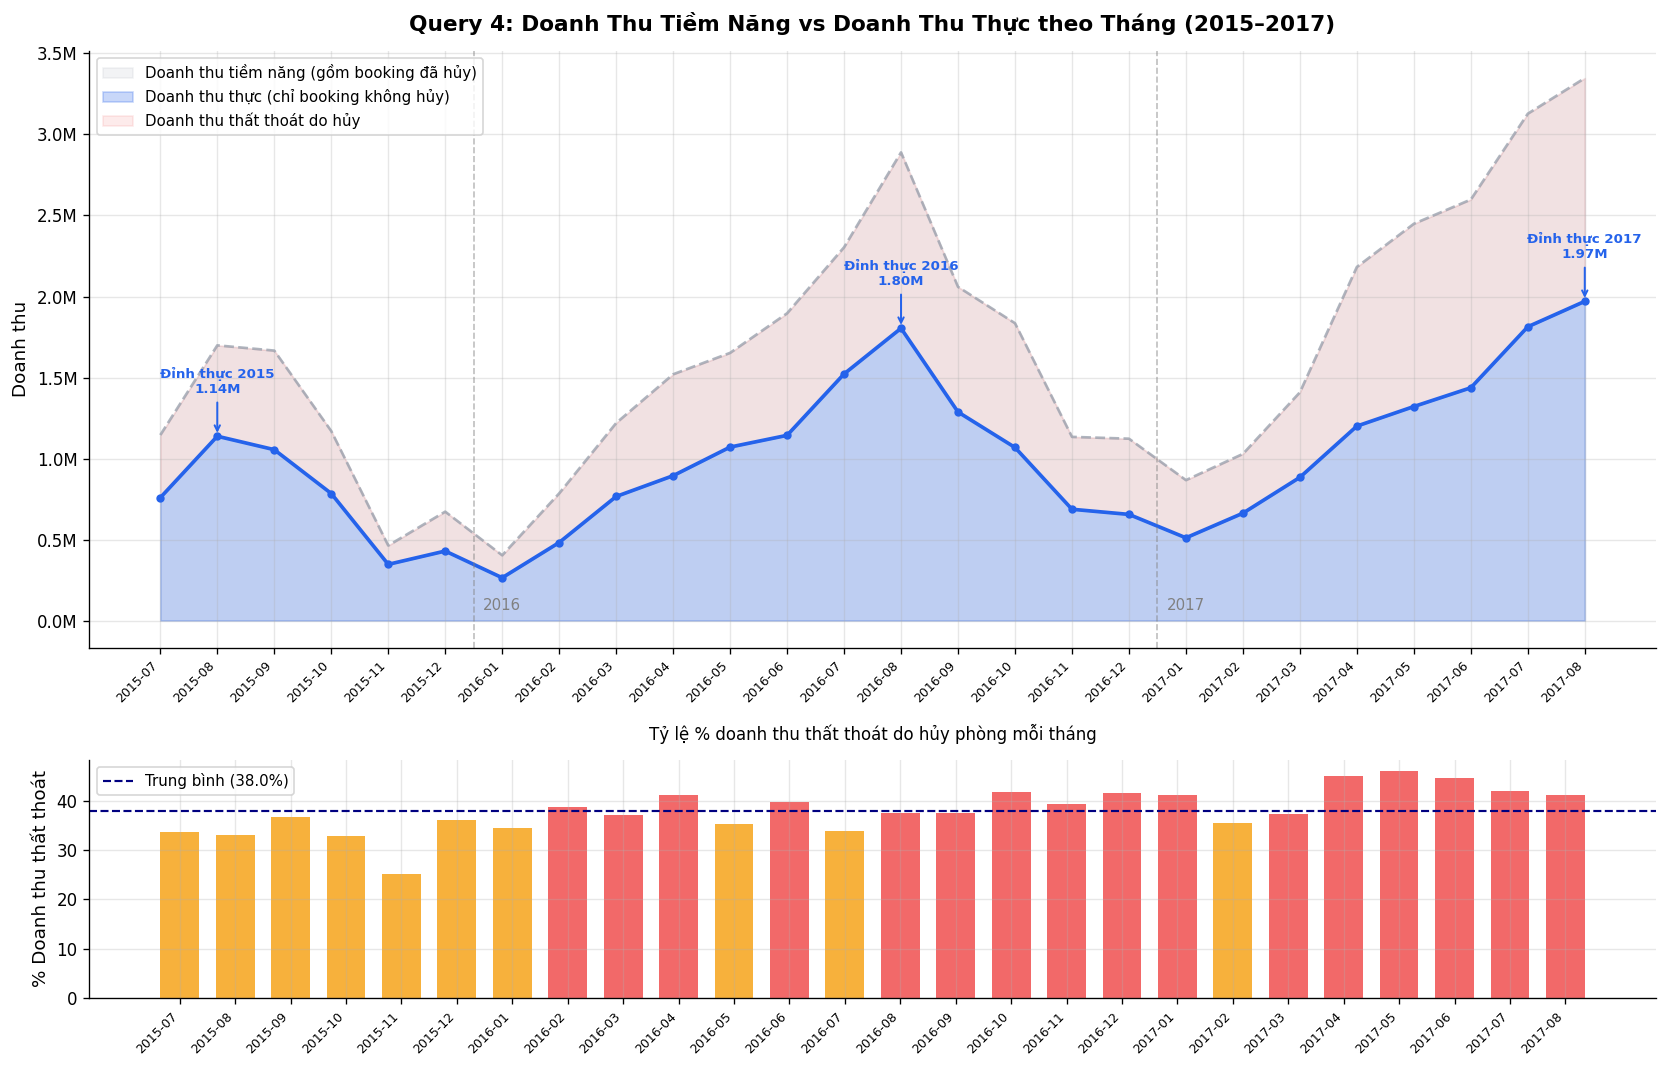

In [7]:
# ── Query 4: Biểu đồ ──────────────────────────────────────
data_q4 = df_q4.toPandas().sort_values(['arrival_date_year','month_num'])
data_q4['time_label'] = data_q4['arrival_date_year'].astype(str)+'-'+data_q4['month_num'].astype(str)
x_pos = range(len(data_q4))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios':[2.5,1]})

# ── Panel 1: Doanh thu tiềm năng vs doanh thu thực ─────────────────────────
pot = data_q4['revenue_potential'].values
act = data_q4['revenue_actual'].values

ax1.fill_between(x_pos, pot, alpha=0.12, color=COLORS['gray'], label='Doanh thu tiềm năng (gồm booking đã hủy)')
ax1.plot(x_pos, pot, color=COLORS['gray'], lw=1.6, ls='--', marker='', alpha=0.8)

ax1.fill_between(x_pos, act, alpha=0.25, color=COLORS['city'], label='Doanh thu thực (chỉ booking không hủy)')
ax1.plot(x_pos, act, color=COLORS['city'], lw=2.2, marker='o', markersize=4)

# Vùng giữa 2 đường = doanh thu thất thoát do hủy
ax1.fill_between(x_pos, act, pot, alpha=0.10, color=COLORS['red'], label='Doanh thu thất thoát do hủy')

# Đánh dấu đỉnh doanh thu thực mỗi năm
for yr in [2015, 2016, 2017]:
    sub = data_q4[data_q4['arrival_date_year'] == yr]
    peak_idx_label = sub['revenue_actual'].idxmax()
    peak_val = sub.loc[peak_idx_label, 'revenue_actual']
    pos_x = list(data_q4.index).index(peak_idx_label)
    ax1.annotate(f'Đỉnh thực {yr}\n{peak_val/1e6:.2f}M',
                  xy=(pos_x, peak_val), xytext=(pos_x, peak_val + pot.max()*0.08),
                  arrowprops=dict(arrowstyle='->', color=COLORS['city'], lw=1.2),
                  fontsize=8, ha='center', color=COLORS['city'], fontweight='bold')

for yr in [2016, 2017]:
    first_pos = list(data_q4['arrival_date_year']).index(yr)
    ax1.axvline(first_pos - 0.5, color='gray', ls='--', lw=1, alpha=0.5)
    ax1.text(first_pos, pot.max()*0.02, str(yr), color='gray', fontsize=9, ha='center')

ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(data_q4['time_label'].tolist(), rotation=45, ha='right', fontsize=7.5)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))
ax1.set_ylabel('Doanh thu')
ax1.set_title('Query 4: Doanh Thu Tiềm Năng vs Doanh Thu Thực theo Tháng (2015–2017)',
               fontweight='bold', fontsize=13)
ax1.legend(fontsize=9, loc='upper left')

# ── Panel 2: % doanh thu thất thoát do hủy mỗi tháng ───────────────────────
lost_pct = data_q4['lost_pct'].values
bar_colors = [COLORS['red'] if v >= 37 else COLORS['resort'] for v in lost_pct]
ax2.bar(list(x_pos), lost_pct, color=bar_colors, alpha=0.8, width=0.7)
ax2.axhline(lost_pct.mean(), color='navy', ls='--', lw=1.3,
            label=f'Trung bình ({lost_pct.mean():.1f}%)')

ax2.set_xticks(list(x_pos))
ax2.set_xticklabels(data_q4['time_label'].tolist(), rotation=45, ha='right', fontsize=7.5)
ax2.set_ylabel('% Doanh thu thất thoát')
ax2.set_title('Tỷ lệ % doanh thu thất thoát do hủy phòng mỗi tháng', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


Query 6: Loại phòng được đặt nhiều nhất trong từng khách sạn

In [ ]:
df_q6 = spark.sql("""
WITH room_booking AS (
    SELECT
        hotel,
        reserved_room_type,
        COUNT(*) AS total_booking
    FROM hotel_bookings
    GROUP BY hotel, reserved_room_type
)
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (PARTITION BY hotel ORDER BY total_booking DESC) AS rank
    FROM room_booking
) x
WHERE rank <= 3
ORDER BY hotel, rank
""")
df_q6.show()

+------------+------------------+-------------+----+
|       hotel|reserved_room_type|total_booking|rank|
+------------+------------------+-------------+----+
|  City Hotel|                 A|        62256|   1|
|  City Hotel|                 D|        11717|   2|
|  City Hotel|                 F|         1781|   3|
|Resort Hotel|                 A|        23117|   1|
|Resort Hotel|                 D|         7374|   2|
|Resort Hotel|                 E|         4950|   3|
+------------+------------------+-------------+----+



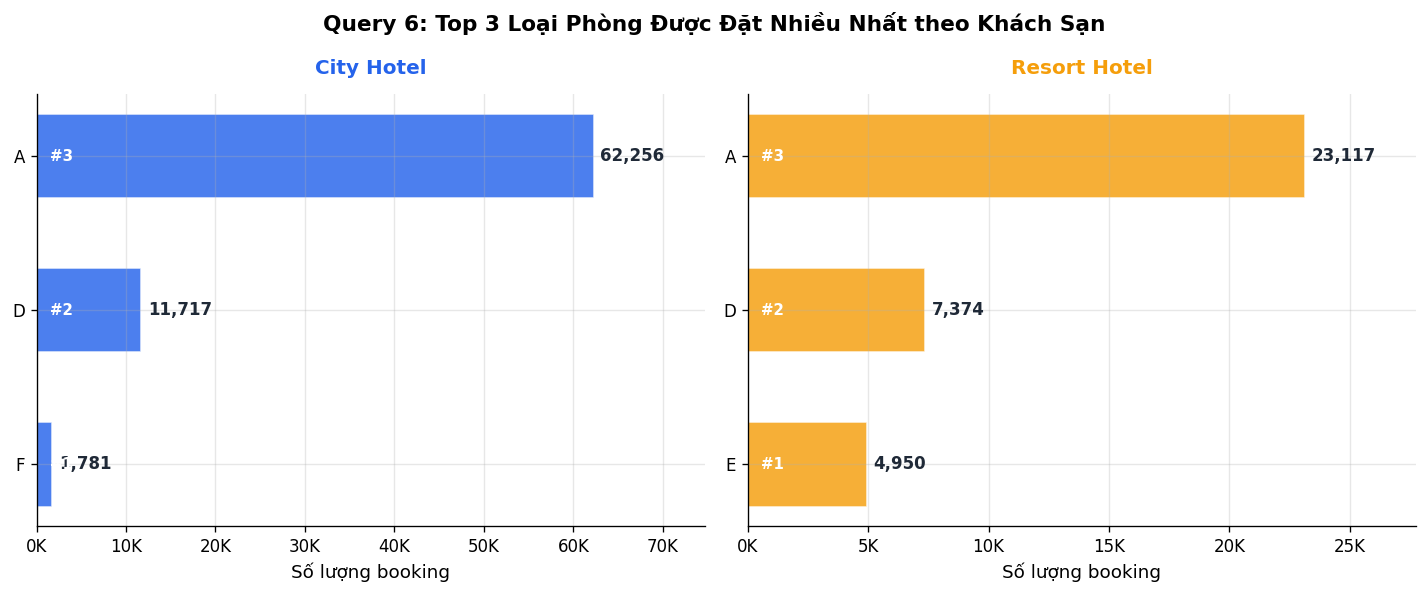

In [9]:
# ── Query 6: Biểu đồ ────────────────────────────────────────────────────────
data = df_q6.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, hotel, color in zip(
    axes,
    ["City Hotel", "Resort Hotel"],
    [COLORS["city"], COLORS["resort"]]
):
    sub   = data[data["hotel"] == hotel].sort_values("total_booking")
    rooms = sub["reserved_room_type"].tolist()
    bks   = sub["total_booking"].tolist()
    ranks = sub["rank"].tolist()

    # Horizontal bar
    bars = ax.barh(rooms, bks, color=color, alpha=0.82,
                   height=0.55, edgecolor="white")

    # Nhãn số lượng
    for bar, val in zip(bars, bks):
        ax.text(val + max(bks) * 0.012,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=10,
                fontweight="bold", color="#1F2937")

    # Nhãn rank trong thanh
    for bar, rk in zip(bars, ranks[::-1]):
        ax.text(max(bks) * 0.025,
                bar.get_y() + bar.get_height() / 2,
                f"#{rk}", va="center", fontsize=9,
                color="white", fontweight="bold")

    ax.set_xlabel("Số lượng booking")
    ax.set_title(hotel, fontsize=12, fontweight="bold", color=color)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}K")
    )
    ax.set_xlim(0, max(bks) * 1.2)

fig.suptitle("Query 6: Top 3 Loại Phòng Được Đặt Nhiều Nhất theo Khách Sạn",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Query 8: Market Segment có tỷ lệ hủy cao nhất

In [ ]:
df_q8 = spark.sql("""
WITH segment_cancel AS (
    SELECT
        market_segment,
        COUNT(*) AS total_booking,
        ROUND(AVG(is_canceled) * 100, 2) AS cancel_rate
    FROM hotel_bookings
    GROUP BY market_segment
)
SELECT *,
       DENSE_RANK() OVER (ORDER BY cancel_rate DESC) AS rank
FROM segment_cancel
ORDER BY cancel_rate DESC
""")
df_q8.show()

+--------------+-------------+-----------+----+
|market_segment|total_booking|cancel_rate|rank|
+--------------+-------------+-----------+----+
|     Undefined|            2|      100.0|   1|
|        Groups|        19758|      61.21|   2|
|     Online TA|        55941|      36.91|   3|
| Offline TA/TO|        24039|       34.5|   4|
|      Aviation|          231|      22.08|   5|
|     Corporate|         5230|      18.91|   6|
|        Direct|        12409|      15.41|   7|
| Complementary|          711|       12.1|   8|
+--------------+-------------+-----------+----+



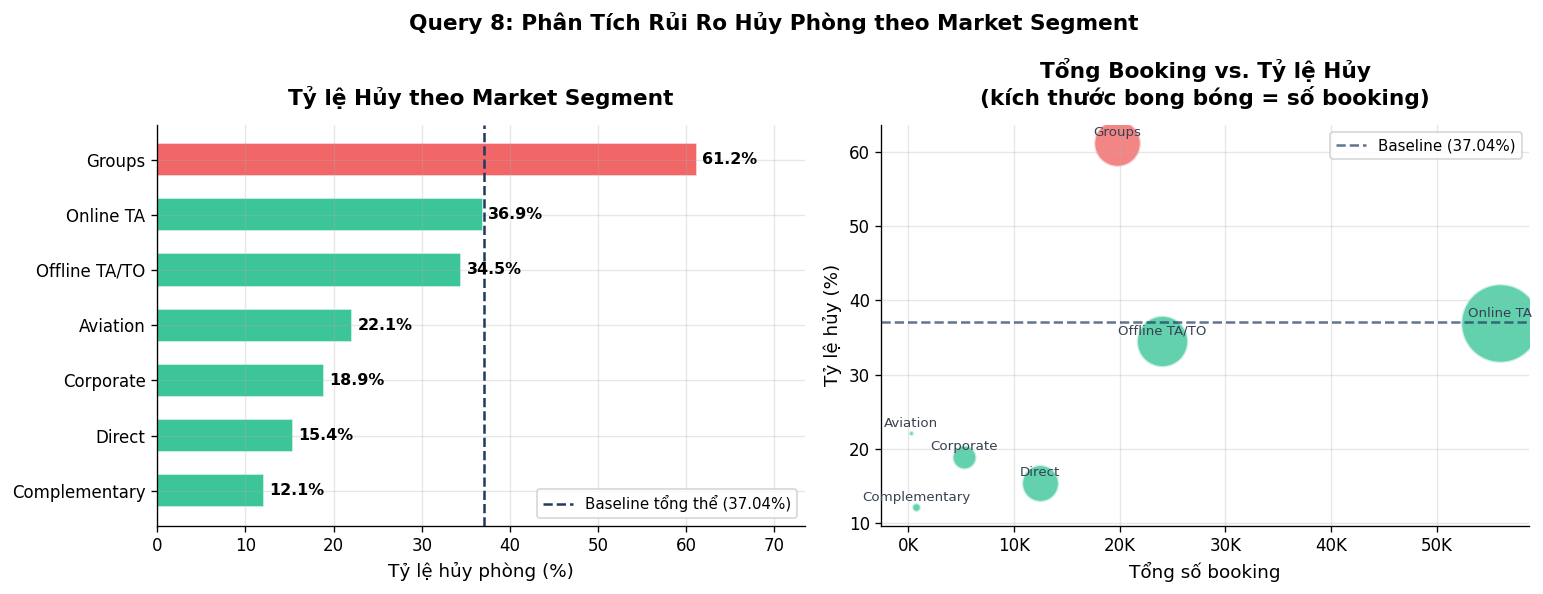

In [11]:
# ── Query 8: Biểu đồ ────────────────────────────────────────────────────────
data = (df_q8.toPandas()
        .query("market_segment != 'Undefined'")
        .sort_values("cancel_rate", ascending=True))

BASELINE = 37.04

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1: Horizontal bar tỷ lệ hủy ──────────────────────────────────────
segs  = data["market_segment"].tolist()
rates = data["cancel_rate"].tolist()
bcolors = [COLORS["red"] if r > BASELINE else COLORS["green"] for r in rates]

bars = ax1.barh(segs, rates, color=bcolors, alpha=0.82, height=0.6, edgecolor="white")
ax1.axvline(BASELINE, color=COLORS["navy"], ls="--", lw=1.5,
            label=f"Baseline tổng thể ({BASELINE}%)")

for bar, val in zip(bars, rates):
    ax1.text(val + 0.6, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9.5, fontweight="bold")

ax1.set_xlabel("Tỷ lệ hủy phòng (%)")
ax1.set_title("Tỷ lệ Hủy theo Market Segment", fontweight="bold")
ax1.set_xlim(0, max(rates) * 1.2)
ax1.legend(fontsize=9)

# ── Panel 2: Bubble chart – volume vs cancel rate ───────────────────────────
bks = data["total_booking"].tolist()
for seg, book, rate in zip(segs, bks, rates):
    ax2.scatter(book, rate,
                s=book / 25,
                color=COLORS["red"] if rate > BASELINE else COLORS["green"],
                alpha=0.65, edgecolors="white", linewidth=1.5)
    ax2.text(book, rate + 0.9, seg, ha="center", fontsize=8, color="#374151")

ax2.axhline(BASELINE, color=COLORS["navy"], ls="--", lw=1.5, alpha=0.7,
            label=f"Baseline ({BASELINE}%)")
ax2.set_xlabel("Tổng số booking")
ax2.set_ylabel("Tỷ lệ hủy (%)")
ax2.set_title("Tổng Booking vs. Tỷ lệ Hủy\n(kích thước bong bóng = số booking)",
              fontweight="bold")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}K"))
ax2.legend(fontsize=9)

fig.suptitle("Query 8: Phân Tích Rủi Ro Hủy Phòng theo Market Segment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Query 10: Ảnh hưởng của special requests đến tỷ lệ hủy

In [ ]:
df_q10 = spark.sql("""
WITH request_stats AS (
    SELECT
        total_of_special_requests,
        COUNT(*) AS total_booking,
        ROUND(AVG(is_canceled) * 100, 2) AS cancel_rate
    FROM hotel_bookings
    GROUP BY total_of_special_requests
)
SELECT *,
       DENSE_RANK() OVER (ORDER BY total_of_special_requests DESC) AS request_rank
FROM request_stats
ORDER BY total_of_special_requests DESC
""")
df_q10.show()

+-------------------------+-------------+-----------+------------+
|total_of_special_requests|total_booking|cancel_rate|request_rank|
+-------------------------+-------------+-----------+------------+
|                        5|           40|        5.0|           1|
|                        4|          338|      10.65|           2|
|                        3|         2472|      17.84|           3|
|                        2|        12853|      22.16|           4|
|                        1|        32905|      22.11|           5|
|                        0|        69713|      48.01|           6|
+-------------------------+-------------+-----------+------------+



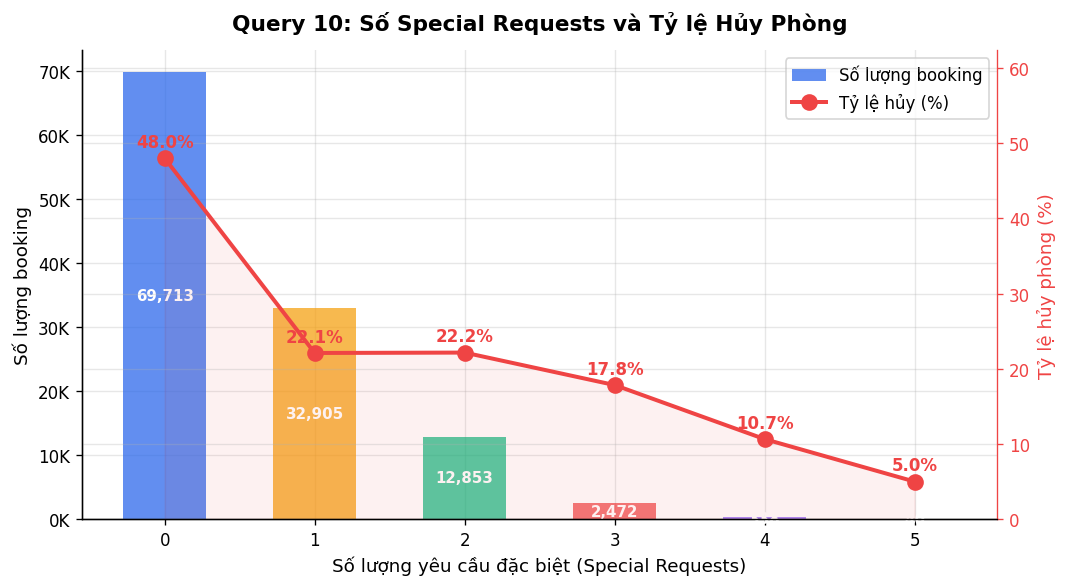

In [13]:
# ── Query 10: Biểu đồ ───────────────────────────────────────────────────────
data = df_q10.toPandas().sort_values("total_of_special_requests")

x_labels = data["total_of_special_requests"].astype(str).tolist()
bks      = data["total_booking"].tolist()
rates    = data["cancel_rate"].tolist()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# ── Bar: số lượng booking ────────────────────────────────────────────────────
bar_colors = COLORS["palette"][:len(x_labels)]
bars = ax1.bar(x_labels, bks, color=bar_colors, alpha=0.72,
               width=0.55, zorder=2, label="Số lượng booking")

# Nhãn số lượng trong thanh bar
for bar, val in zip(bars, bks):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 0.5,
             f"{val:,}", ha="center", va="center",
             fontsize=9, color="white", fontweight="bold")

# ── Line: tỷ lệ hủy ─────────────────────────────────────────────────────────
ax2.plot(x_labels, rates, "o-", color=COLORS["red"],
         lw=2.4, markersize=9, zorder=3, label="Tỷ lệ hủy (%)")
ax2.fill_between(x_labels, rates, alpha=0.07, color=COLORS["red"])

# Nhãn % trên mỗi điểm
for xi, rate in zip(x_labels, rates):
    ax2.text(xi, rate + 1.5, f"{rate:.1f}%",
             ha="center", fontsize=10,
             color=COLORS["red"], fontweight="bold")

# ── Axes config ───────────────────────────────────────────────────────────────
ax1.set_xlabel("Số lượng yêu cầu đặc biệt (Special Requests)", fontsize=11)
ax1.set_ylabel("Số lượng booking", fontsize=11)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v/1000)}K")
)

ax2.set_ylabel("Tỷ lệ hủy phòng (%)", fontsize=11, color=COLORS["red"])
ax2.tick_params(axis="y", colors=COLORS["red"])
ax2.set_ylim(0, max(rates) * 1.3)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(COLORS["red"])

ax1.set_title("Query 10: Số Special Requests và Tỷ lệ Hủy Phòng",
              fontweight="bold")

# Legend kết hợp 2 trục
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, fontsize=10, loc="upper right")

plt.tight_layout()
plt.show()

Query 12: Top 3 tháng có doanh thu cao nhất mỗi năm

In [ ]:
df_q12 = spark.sql("""
WITH monthly_revenue AS (
    SELECT
        arrival_date_year,
        DATE_FORMAT(TO_DATE(arrival_date_month, 'MMMM'), 'MM') AS month_num,
        arrival_date_month AS month_name,
        ROUND(SUM(adr * (stays_in_week_nights + stays_in_weekend_nights))) AS revenue
    FROM hotel_bookings
    GROUP BY arrival_date_year, month_num, month_name
)
SELECT *
FROM (
    SELECT *,
           DENSE_RANK() OVER (PARTITION BY arrival_date_year ORDER BY revenue DESC) AS rank
    FROM monthly_revenue
) x
WHERE rank <= 3
ORDER BY arrival_date_year, rank
""")
df_q12.show()

+-----------------+---------+----------+---------+----+
|arrival_date_year|month_num|month_name|  revenue|rank|
+-----------------+---------+----------+---------+----+
|             2015|       08|    August|1698507.0|   1|
|             2015|       09| September|1666155.0|   2|
|             2015|       10|   October|1169505.0|   3|
|             2016|       08|    August|2889627.0|   1|
|             2016|       07|      July|2303695.0|   2|
|             2016|       09| September|2059457.0|   3|
|             2017|       08|    August|3347905.0|   1|
|             2017|       07|      July|3128244.0|   2|
|             2017|       06|      June|2598435.0|   3|
+-----------------+---------+----------+---------+----+



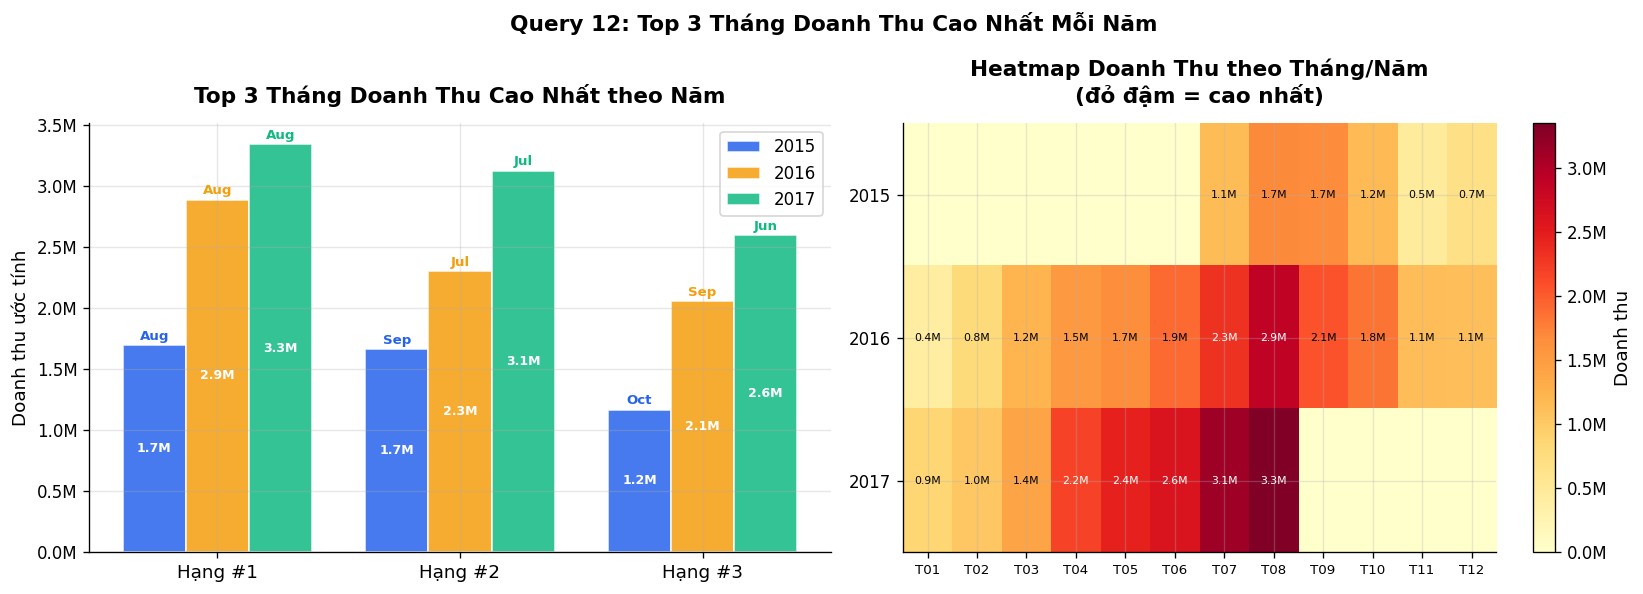

In [15]:
# ── Query 12: Biểu đồ ───────────────────────────────────────────────────────
import pandas as pd

data_top3 = df_q12.toPandas()

# Lấy toàn bộ doanh thu tháng để vẽ heatmap
df_all = spark.sql("""
    SELECT
        arrival_date_year,
        DATE_FORMAT(TO_DATE(arrival_date_month, 'MMMM'), 'MM') AS month_num,
        ROUND(SUM(adr * (stays_in_week_nights + stays_in_weekend_nights))) AS revenue
    FROM hotel_bookings
    GROUP BY arrival_date_year, month_num
    ORDER BY arrival_date_year, month_num
""").toPandas()

pivot = df_all.pivot(index="arrival_date_year",
                     columns="month_num",
                     values="revenue").fillna(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Grouped Bar – Top 3 theo từng năm ──────────────────────────────
years_list = sorted(data_top3["arrival_date_year"].unique())
yr_colors  = [COLORS["city"], COLORS["resort"], COLORS["green"]]
x_rk       = np.arange(3)

for i, (yr, col) in enumerate(zip(years_list, yr_colors)):
    sub    = data_top3[data_top3["arrival_date_year"] == yr].sort_values("rank")
    revs   = sub["revenue"].tolist()
    months = sub["month_name"].str[:3].tolist()

    bars = ax1.bar(x_rk + (i - 1) * 0.26, revs, 0.26,
                   label=str(yr), color=col, alpha=0.85, edgecolor="white")

    for bar, mth, rev in zip(bars, months, revs):
        # Tên tháng phía trên thanh
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 18000,
                 mth, ha="center", va="bottom",
                 fontsize=8, fontweight="bold", color=col)
        # Giá trị trong thanh
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() / 2,
                 f"{rev/1e6:.1f}M", ha="center", va="center",
                 fontsize=7.5, color="white", fontweight="bold")

ax1.set_xticks(x_rk)
ax1.set_xticklabels(["Hạng #1", "Hạng #2", "Hạng #3"], fontsize=11)
ax1.set_ylabel("Doanh thu ước tính")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M")
)
ax1.set_title("Top 3 Tháng Doanh Thu Cao Nhất theo Năm",
              fontweight="bold")
ax1.legend(fontsize=10)

# ── Panel 2: Heatmap toàn bộ doanh thu theo tháng/năm ───────────────────────
im = ax2.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels([f"T{c}" for c in pivot.columns], fontsize=8)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index.tolist(), fontsize=10)
ax2.set_title("Heatmap Doanh Thu theo Tháng/Năm\n(đỏ đậm = cao nhất)",
              fontweight="bold")

# Nhãn giá trị trong ô heatmap
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i][j]
        txt_color = "white" if val > pivot.values.max() * 0.62 else "black"
        ax2.text(j, i, f"{val/1e6:.1f}M" if val > 0 else "",
                 ha="center", va="center",
                 fontsize=6.5, color=txt_color)

plt.colorbar(im, ax=ax2, label="Doanh thu",
             format=mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))

fig.suptitle("Query 12: Top 3 Tháng Doanh Thu Cao Nhất Mỗi Năm",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()